# Modified SCGTNet — Training & Evaluasi
**Dataset**: NinaPro DB5  
**Arsitektur**: Modified SCGTNet (GRU → Bi-GRU)  
**Strategi**: 20% Unseen Test Set + 5-Fold Cross Validation (Subject-Based)

---
## Solusi Data Leakage
Pembagian data dilakukan berdasarkan **subjek**, bukan window secara acak.
Karena windowing menggunakan 50% overlap, window yang berurutan memiliki
sampel yang sama. Jika dibagi secara acak, window overlap bisa tersebar
di training dan validasi sekaligus (data leakage).

Dengan **subject-based split**, seluruh window dari satu subjek hanya
masuk ke satu subset saja (training ATAU validasi), tidak pernah keduanya.

```
10 Subjek Total
        ↓
Pisahkan 2 subjek → Unseen Test Set (20%)
        ↓
8 subjek sisanya → 5-Fold Cross Validation
  Fold 1: Subjek [1,2] Val | Subjek [3,4,5,6,7,8] Train
  Fold 2: Subjek [3,4] Val | Subjek [1,2,5,6,7,8] Train
  Fold 3: Subjek [5,6] Val | Subjek [1,2,3,4,7,8] Train
  Fold 4: Subjek [7]   Val | Subjek [1,2,3,4,5,6,8] Train
  Fold 5: Subjek [8]   Val | Subjek [1,2,3,4,5,6,7] Train
        ↓
Rata-rata metrik 5 fold
        ↓
Evaluasi model terbaik pada Unseen Test Set
```

## Cell 1 — Import Library

In [2]:
import numpy as np
import scipy.io as sio
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from models.modified_scgtnet import build_modified_scgtnet

print('TensorFlow version :', tf.__version__)
print('GPU tersedia        :', tf.config.list_physical_devices('GPU'))
print('Library siap!')

TensorFlow version : 2.21.0
GPU tersedia        : []
Library siap!


## Cell 2 — Konfigurasi

In [3]:
# ── Path ──────────────────────────────────────────────────
DATA_PATH  = 'data/windows/all_subjects_windows.mat'
MODEL_DIR  = 'results/models/02'
RESULT_DIR = 'results/figures/02'
UNSEEN_DATA_DIR = 'results/unseen_data/02'

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(UNSEEN_DATA_DIR, exist_ok=True)
os.makedirs('results',  exist_ok=True)

# ── Parameter Data ────────────────────────────────────────
T          = 40     # panjang window
C          = 16     # jumlah kanal
N_CLASSES  = 52     # jumlah kelas gestur
N_SUBJECTS = 10     # jumlah subjek NinaPro DB5

# ── Pembagian Subjek ──────────────────────────────────────
# 2 subjek untuk unseen test set, 8 subjek untuk cross validation
# Subjek ID pada file .mat (1-based)
TEST_SUBJECTS  = [9, 10]         # subjek untuk unseen test set
TRAIN_SUBJECTS = [1,2,3,4,5,6,7,8]  # subjek untuk cross validation

# Pembagian fold berdasarkan subjek
# Setiap fold menentukan subjek mana yang menjadi validasi
FOLD_SUBJECTS = [
    [1, 2],    # fold 1: subjek 1,2 → validasi
    [3, 4],    # fold 2: subjek 3,4 → validasi
    [5, 6],    # fold 3: subjek 5,6 → validasi
    [7],       # fold 4: subjek 7   → validasi
    [8],       # fold 5: subjek 8   → validasi
]

# ── Parameter Training ────────────────────────────────────
N_FOLDS       = 5
BATCH_SIZE    = 256
MAX_EPOCHS    = 200
LEARNING_RATE = 0.001
PATIENCE      = 10
RANDOM_STATE  = 42

# ── Parameter Model ───────────────────────────────────────
MSC_FILTERS  = 16
GRU_UNITS    = 64
NUM_HEADS    = 4
DROPOUT_RATE = 0.1

print('Konfigurasi:')
print(f'  Input shape     : ({T}, {C})')
print(f'  Jumlah kelas    : {N_CLASSES}')
print(f'  Test subjects   : {TEST_SUBJECTS}')
print(f'  Train subjects  : {TRAIN_SUBJECTS}')
print(f'  K-Fold          : {N_FOLDS}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Max epochs      : {MAX_EPOCHS}')
print(f'  Learning rate   : {LEARNING_RATE}')
print(f'  Early stop      : {PATIENCE} epoch')

Konfigurasi:
  Input shape     : (40, 16)
  Jumlah kelas    : 52
  Test subjects   : [9, 10]
  Train subjects  : [1, 2, 3, 4, 5, 6, 7, 8]
  K-Fold          : 5
  Batch size      : 256
  Max epochs      : 200
  Learning rate   : 0.001
  Early stop      : 10 epoch


## Cell 3 — Load Data

In [4]:
print('Memuat data...')
data       = sio.loadmat(DATA_PATH)
windows    = data['windows'].astype(np.float32)       # (N, 40, 16)
labels     = data['labels'].flatten().astype(np.int32)     # (N,)
subject_id = data['subject_id'].flatten().astype(np.int32) # (N,)

print(f'Shape windows    : {windows.shape}')
print(f'Shape labels     : {labels.shape}')
print(f'Shape subject_id : {subject_id.shape}')
print(f'Subjek unik      : {np.unique(subject_id)}')
print(f'Label unik       : {np.unique(labels)}')
print(f'Jumlah kelas     : {len(np.unique(labels))}')

# Remap label ke 0-based (1-52 → 0-51)
label_asli = np.unique(labels)
label_map  = {lama: baru for baru, lama in enumerate(label_asli)}
labels_idx = np.array([label_map[l] for l in labels], dtype=np.int32)

print(f'\nLabel setelah remap: min={labels_idx.min()}, max={labels_idx.max()}')

# Distribusi window per subjek
print('\nDistribusi window per subjek:')
for sid in np.unique(subject_id):
    jumlah = np.sum(subject_id == sid)
    print(f'  Subjek {sid:2d}: {jumlah} window')

Memuat data...
Shape windows    : (183251, 40, 16)
Shape labels     : (183251,)
Shape subject_id : (183251,)
Subjek unik      : [ 1  2  3  4  5  6  7  8  9 10]
Label unik       : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52]
Jumlah kelas     : 52

Label setelah remap: min=0, max=51

Distribusi window per subjek:
  Subjek  1: 16853 window
  Subjek  2: 18543 window
  Subjek  3: 16835 window
  Subjek  4: 18815 window
  Subjek  5: 18634 window
  Subjek  6: 18783 window
  Subjek  7: 18786 window
  Subjek  8: 18642 window
  Subjek  9: 18659 window
  Subjek 10: 18701 window


## Cell 4 — Pisahkan Unseen Test Set (Subject-Based)

In [5]:
def get_idx_by_subjects(subject_id, subject_list):
    """Ambil indeks window berdasarkan daftar subjek."""
    mask = np.isin(subject_id, subject_list)
    return np.where(mask)[0]

# Pisahkan berdasarkan subjek
test_idx     = get_idx_by_subjects(subject_id, TEST_SUBJECTS)
trainval_idx = get_idx_by_subjects(subject_id, TRAIN_SUBJECTS)

X_test     = windows[test_idx]
y_test     = labels_idx[test_idx]

X_trainval = windows[trainval_idx]
y_trainval = labels_idx[trainval_idx]
sid_trainval = subject_id[trainval_idx]

print('Pembagian data (Subject-Based):')
print(f'  Total windows      : {len(windows)}')
print(f'  Unseen test set    : {len(X_test)} window (Subjek {TEST_SUBJECTS})')
print(f'  Train+Val          : {len(X_trainval)} window (Subjek {TRAIN_SUBJECTS})')
print(f'\nShape X_test         : {X_test.shape}')
print(f'Shape X_trainval     : {X_trainval.shape}')

# Simpan unseen test set
np.save(f'{UNSEEN_DATA_DIR}/X_test_unseen.npy', X_test)
np.save(f'{UNSEEN_DATA_DIR}/y_test_unseen.npy', y_test)
print('\nUnseen test set tersimpan — tidak digunakan sampai akhir!')

Pembagian data (Subject-Based):
  Total windows      : 183251
  Unseen test set    : 37360 window (Subjek [9, 10])
  Train+Val          : 145891 window (Subjek [1, 2, 3, 4, 5, 6, 7, 8])

Shape X_test         : (37360, 40, 16)
Shape X_trainval     : (145891, 40, 16)

Unseen test set tersimpan — tidak digunakan sampai akhir!


## Cell 5 — Fungsi Helper

In [6]:
def hitung_metrik(y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1


def plot_history(history, fold, save_dir):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validasi')
    ax1.set_title(f'Akurasi — Fold {fold}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Akurasi')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validasi')
    ax2.set_title(f'Loss — Fold {fold}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'history_fold_{fold}.png'), dpi=150)
    plt.show()
    plt.close()


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        xticklabels=range(1, N_CLASSES + 1),
        yticklabels=range(1, N_CLASSES + 1)
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Prediksi', fontsize=12)
    plt.ylabel('Label Sebenarnya', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()


print('Fungsi helper siap!')

Fungsi helper siap!


## Cell 6 — 5-Fold Cross Validation (Subject-Based)

  5-FOLD CROSS VALIDATION (SUBJECT-BASED)
  Tidak ada data leakage antar window overlap

[FOLD 1/5]
  Val subjects   : [1, 2]
  Train subjects : [3, 4, 5, 6, 7, 8]
------------------------------------------------------------
  Train : 110495 window
  Val   : 35396 window

Epoch 1/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.1070 - loss: 3.5168

432/432 ━━━━━━━━━━━━━━━━━━━━ 180s 396ms/step - accuracy: 0.1513 - loss: 3.2600 - val_accuracy: 0.1006 - val_loss: 3.7722 - learning_rate: 0.0010
Epoch 2/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2402 - loss: 2.7909

432/432 ━━━━━━━━━━━━━━━━━━━━ 170s 393ms/step - accuracy: 0.2579 - loss: 2.7106 - val_accuracy: 0.1121 - val_loss: 3.9003 - learning_rate: 0.0010
Epoch 3/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.3192 - loss: 2.4329

432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 399ms/step - accuracy: 0.3314 - loss: 2.3803 - val_accuracy: 0.1150 - val_loss: 4.1198 - learning_rate: 0.0010
Epoch 4/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 397ms/step - accuracy: 0.3918 - loss: 2.1257 - val_accuracy: 0.1126 - val_loss: 4.3708 - learning_rate: 0.0010
Epoch 5/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 171s 397ms/step - accuracy: 0.4443 - loss: 1.9168 - val_accuracy: 0.1114 - val_loss: 4.6399 - learning_rate: 0.0010
Epoch 6/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 171s 396ms/step - accuracy: 0.4857 - loss: 1.7527 - val_accuracy: 0.1092 - val_loss: 4.7855 - learning_rate: 0.0010
Epoch 7/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 398ms/step - accuracy: 0.5515 - loss: 1.5128 - val_accuracy: 0.1146 - val_loss: 5.0279 - learning_rate: 5.0000e-04
Epoch 8/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.5784 - loss: 1.4115

432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 399ms/step - accuracy: 0.5744 - loss: 1.4214 - val_accuracy: 0.1154 - val_loss: 5.2153 - learning_rate: 5.0000e-04
Epoch 9/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 171s 397ms/step - accuracy: 0.5938 - loss: 1.3469 - val_accuracy: 0.1089 - val_loss: 5.4078 - learning_rate: 5.0000e-04
Epoch 10/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 399ms/step - accuracy: 0.6091 - loss: 1.2841 - val_accuracy: 0.1057 - val_loss: 5.7041 - learning_rate: 5.0000e-04
Epoch 11/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 171s 397ms/step - accuracy: 0.6254 - loss: 1.2229 - val_accuracy: 0.1073 - val_loss: 5.7991 - learning_rate: 5.0000e-04
Epoch 12/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 398ms/step - accuracy: 0.6658 - loss: 1.0954 - val_accuracy: 0.1089 - val_loss: 5.9376 - learning_rate: 2.5000e-04
Epoch 13/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 172s 399ms/step - accuracy: 0.6771 - loss: 1.0575 - val_accuracy: 0.1059 - val_loss: 6.0786 - learning_rate: 2.5000e-04
Epoch 14/200
432/432 ━━━━━━━━━━━━━━━━━━━━ 

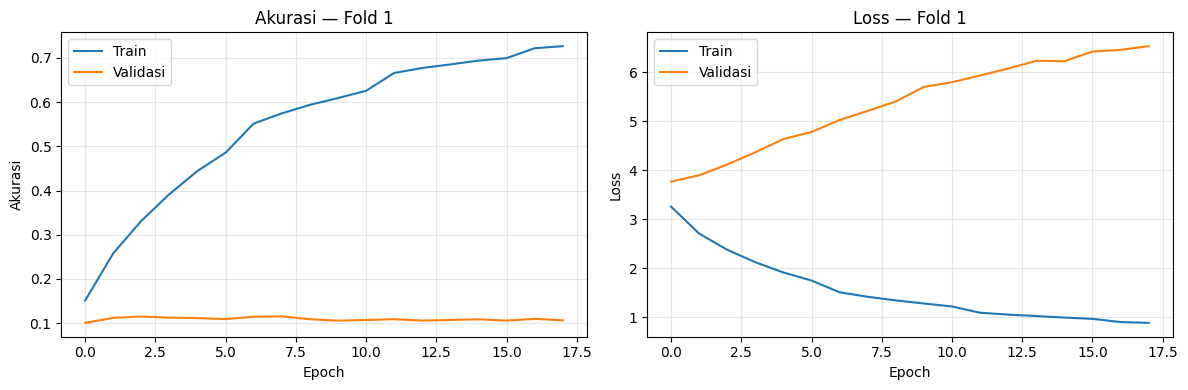


[FOLD 2/5]
  Val subjects   : [3, 4]
  Train subjects : [1, 2, 5, 6, 7, 8]
------------------------------------------------------------
  Train : 110241 window
  Val   : 35650 window
Epoch 1/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.1200 - loss: 3.4356

431/431 ━━━━━━━━━━━━━━━━━━━━ 181s 402ms/step - accuracy: 0.1648 - loss: 3.1694 - val_accuracy: 0.0907 - val_loss: 4.0360 - learning_rate: 0.0010
Epoch 2/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.2598 - loss: 2.7058

431/431 ━━━━━━━━━━━━━━━━━━━━ 172s 398ms/step - accuracy: 0.2798 - loss: 2.6200 - val_accuracy: 0.0948 - val_loss: 4.2680 - learning_rate: 0.0010
Epoch 3/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 171s 398ms/step - accuracy: 0.3534 - loss: 2.2986 - val_accuracy: 0.0883 - val_loss: 4.6472 - learning_rate: 0.0010
Epoch 4/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.4059 - loss: 2.0866

431/431 ━━━━━━━━━━━━━━━━━━━━ 171s 398ms/step - accuracy: 0.4127 - loss: 2.0525 - val_accuracy: 0.0949 - val_loss: 4.8969 - learning_rate: 0.0010
Epoch 5/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 173s 401ms/step - accuracy: 0.4612 - loss: 1.8585 - val_accuracy: 0.0849 - val_loss: 5.1599 - learning_rate: 0.0010
Epoch 6/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 173s 402ms/step - accuracy: 0.5017 - loss: 1.7028 - val_accuracy: 0.0845 - val_loss: 5.5374 - learning_rate: 0.0010
Epoch 7/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 173s 401ms/step - accuracy: 0.5667 - loss: 1.4729 - val_accuracy: 0.0833 - val_loss: 5.8447 - learning_rate: 5.0000e-04
Epoch 8/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 173s 400ms/step - accuracy: 0.5904 - loss: 1.3825 - val_accuracy: 0.0847 - val_loss: 6.0617 - learning_rate: 5.0000e-04
Epoch 9/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 172s 399ms/step - accuracy: 0.6108 - loss: 1.3106 - val_accuracy: 0.0882 - val_loss: 6.1868 - learning_rate: 5.0000e-04
Epoch 10/200
431/431 ━━━━━━━━━━━━━━━━━━━━ 173s 401ms/step 

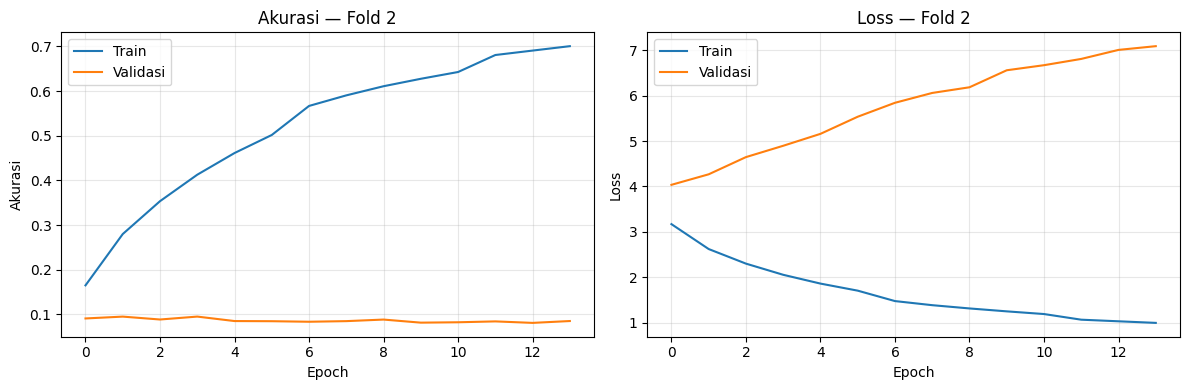


[FOLD 3/5]
  Val subjects   : [5, 6]
  Train subjects : [1, 2, 3, 4, 7, 8]
------------------------------------------------------------
  Train : 108474 window
  Val   : 37417 window
Epoch 1/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.1089 - loss: 3.5358

424/424 ━━━━━━━━━━━━━━━━━━━━ 179s 404ms/step - accuracy: 0.1486 - loss: 3.2930 - val_accuracy: 0.0698 - val_loss: 3.8902 - learning_rate: 0.0010
Epoch 2/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.2304 - loss: 2.8529

424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 400ms/step - accuracy: 0.2457 - loss: 2.7759 - val_accuracy: 0.0835 - val_loss: 4.1243 - learning_rate: 0.0010
Epoch 3/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 401ms/step - accuracy: 0.3109 - loss: 2.4881 - val_accuracy: 0.0813 - val_loss: 4.4509 - learning_rate: 0.0010
Epoch 4/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 401ms/step - accuracy: 0.3642 - loss: 2.2671 - val_accuracy: 0.0782 - val_loss: 4.7299 - learning_rate: 0.0010
Epoch 5/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 169s 400ms/step - accuracy: 0.4071 - loss: 2.0877 - val_accuracy: 0.0786 - val_loss: 5.0138 - learning_rate: 0.0010
Epoch 6/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.4467 - loss: 1.9351

424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 400ms/step - accuracy: 0.4456 - loss: 1.9326 - val_accuracy: 0.0844 - val_loss: 5.3219 - learning_rate: 0.0010
Epoch 7/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 169s 398ms/step - accuracy: 0.5079 - loss: 1.6992 - val_accuracy: 0.0801 - val_loss: 5.5538 - learning_rate: 5.0000e-04
Epoch 8/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 400ms/step - accuracy: 0.5317 - loss: 1.6067 - val_accuracy: 0.0817 - val_loss: 5.8041 - learning_rate: 5.0000e-04
Epoch 9/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 169s 399ms/step - accuracy: 0.5523 - loss: 1.5314 - val_accuracy: 0.0771 - val_loss: 5.9481 - learning_rate: 5.0000e-04
Epoch 10/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 169s 399ms/step - accuracy: 0.5679 - loss: 1.4666 - val_accuracy: 0.0803 - val_loss: 6.1028 - learning_rate: 5.0000e-04
Epoch 11/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 169s 398ms/step - accuracy: 0.5840 - loss: 1.4051 - val_accuracy: 0.0829 - val_loss: 6.2869 - learning_rate: 5.0000e-04
Epoch 12/200
424/424 ━━━━━━━━━━━━━━━━━━━━ 170s 4

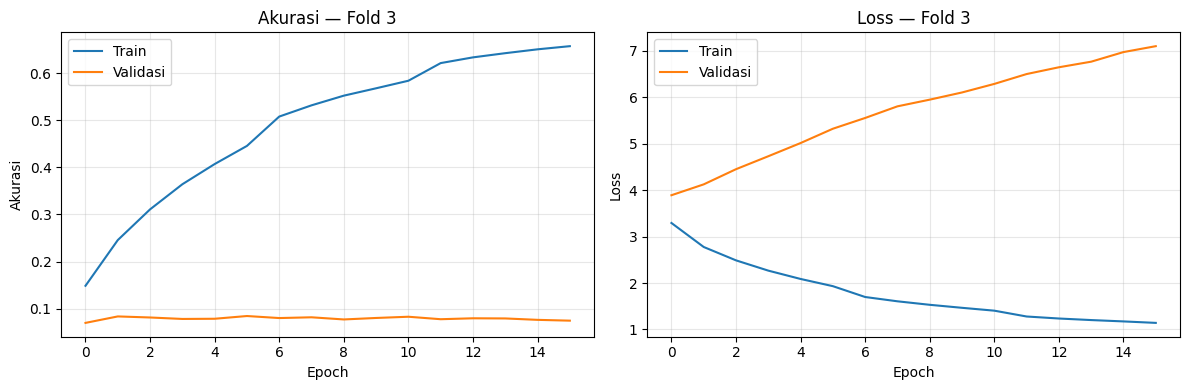


[FOLD 4/5]
  Val subjects   : [7]
  Train subjects : [1, 2, 3, 4, 5, 6, 8]
------------------------------------------------------------
  Train : 127105 window
  Val   : 18786 window
Epoch 1/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.1208 - loss: 3.4542

497/497 ━━━━━━━━━━━━━━━━━━━━ 198s 380ms/step - accuracy: 0.1637 - loss: 3.1960 - val_accuracy: 0.1328 - val_loss: 3.5345 - learning_rate: 0.0010
Epoch 2/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.2602 - loss: 2.6998

497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 381ms/step - accuracy: 0.2808 - loss: 2.6067 - val_accuracy: 0.1421 - val_loss: 3.8071 - learning_rate: 0.0010
Epoch 3/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3511 - loss: 2.3080

497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 380ms/step - accuracy: 0.3632 - loss: 2.2529 - val_accuracy: 0.1434 - val_loss: 3.9888 - learning_rate: 0.0010
Epoch 4/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 379ms/step - accuracy: 0.4249 - loss: 1.9986 - val_accuracy: 0.1364 - val_loss: 4.4602 - learning_rate: 0.0010
Epoch 5/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.4722 - loss: 1.8129

497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 378ms/step - accuracy: 0.4739 - loss: 1.8026 - val_accuracy: 0.1445 - val_loss: 4.5325 - learning_rate: 0.0010
Epoch 6/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 379ms/step - accuracy: 0.5125 - loss: 1.6522 - val_accuracy: 0.1389 - val_loss: 4.6099 - learning_rate: 0.0010
Epoch 7/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 379ms/step - accuracy: 0.5777 - loss: 1.4226 - val_accuracy: 0.1371 - val_loss: 4.9496 - learning_rate: 5.0000e-04
Epoch 8/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 380ms/step - accuracy: 0.6002 - loss: 1.3396 - val_accuracy: 0.1335 - val_loss: 5.2124 - learning_rate: 5.0000e-04
Epoch 9/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 377ms/step - accuracy: 0.6165 - loss: 1.2763 - val_accuracy: 0.1382 - val_loss: 5.2325 - learning_rate: 5.0000e-04
Epoch 10/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 378ms/step - accuracy: 0.6326 - loss: 1.2159 - val_accuracy: 0.1335 - val_loss: 5.3815 - learning_rate: 5.0000e-04
Epoch 11/200
497/497 ━━━━━━━━━━━━━━━━━━━━ 188s 378ms/

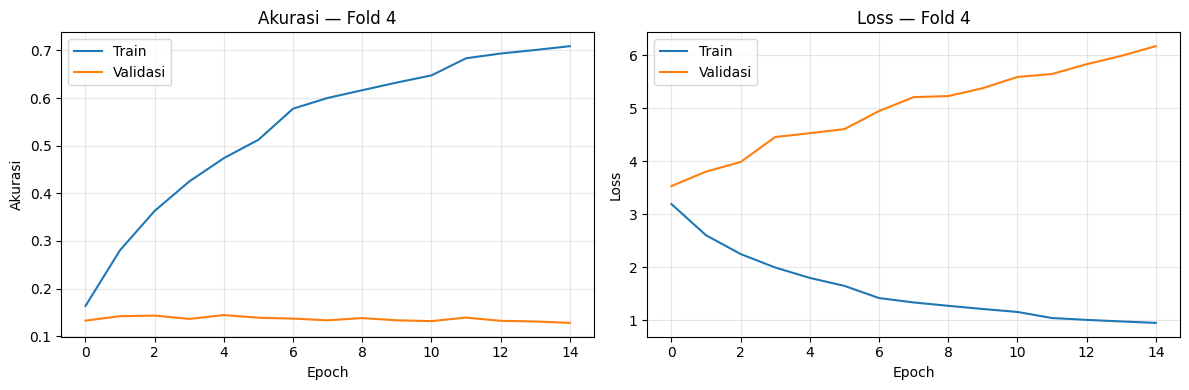


[FOLD 5/5]
  Val subjects   : [8]
  Train subjects : [1, 2, 3, 4, 5, 6, 7]
------------------------------------------------------------
  Train : 127249 window
  Val   : 18642 window
Epoch 1/200
497/498 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.1176 - loss: 3.4751

498/498 ━━━━━━━━━━━━━━━━━━━━ 201s 387ms/step - accuracy: 0.1609 - loss: 3.2141 - val_accuracy: 0.1084 - val_loss: 3.6028 - learning_rate: 0.0010
Epoch 2/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 191s 383ms/step - accuracy: 0.2850 - loss: 2.5927 - val_accuracy: 0.0989 - val_loss: 3.8002 - learning_rate: 0.0010
Epoch 3/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 184s 370ms/step - accuracy: 0.3783 - loss: 2.1995 - val_accuracy: 0.1043 - val_loss: 4.1552 - learning_rate: 0.0010
Epoch 4/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 182s 365ms/step - accuracy: 0.4452 - loss: 1.9290 - val_accuracy: 0.0981 - val_loss: 4.3680 - learning_rate: 0.0010
Epoch 5/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 184s 370ms/step - accuracy: 0.4933 - loss: 1.7292 - val_accuracy: 0.0999 - val_loss: 4.5270 - learning_rate: 0.0010
Epoch 6/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 184s 369ms/step - accuracy: 0.5325 - loss: 1.5741 - val_accuracy: 0.0924 - val_loss: 4.7588 - learning_rate: 0.0010
Epoch 7/200
498/498 ━━━━━━━━━━━━━━━━━━━━ 183s 368ms/step - accuracy: 0

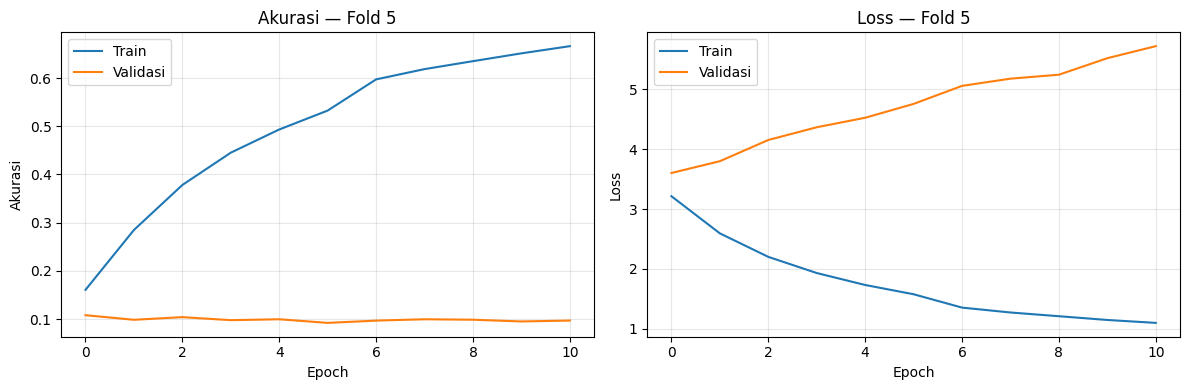


  5-FOLD SELESAI


In [7]:
hasil_fold    = []
best_val_acc  = 0.0
best_fold     = -1
best_model_path = ''

print('=' * 60)
print('  5-FOLD CROSS VALIDATION (SUBJECT-BASED)')
print('  Tidak ada data leakage antar window overlap')
print('=' * 60)

for fold, val_subjects in enumerate(FOLD_SUBJECTS, start=1):

    # Subjek training = semua subjek trainval KECUALI val_subjects
    train_subjects_fold = [s for s in TRAIN_SUBJECTS if s not in val_subjects]

    print(f'\n[FOLD {fold}/{N_FOLDS}]')
    print(f'  Val subjects   : {val_subjects}')
    print(f'  Train subjects : {train_subjects_fold}')
    print('-' * 60)

    # ── Ambil indeks berdasarkan subjek ───────────────────
    train_idx = get_idx_by_subjects(sid_trainval, train_subjects_fold)
    val_idx   = get_idx_by_subjects(sid_trainval, val_subjects)

    X_train = X_trainval[train_idx]
    y_train = y_trainval[train_idx]
    X_val   = X_trainval[val_idx]
    y_val   = y_trainval[val_idx]

    print(f'  Train : {len(X_train)} window')
    print(f'  Val   : {len(X_val)} window')

    # ── One-hot encoding ──────────────────────────────────
    y_train_oh = to_categorical(y_train, num_classes=N_CLASSES)
    y_val_oh   = to_categorical(y_val,   num_classes=N_CLASSES)

    # ── Build model baru setiap fold ─────────────────────
    tf.keras.backend.clear_session()
    model = build_modified_scgtnet(
        T            = T,
        C            = C,
        n_classes    = N_CLASSES,
        msc_filters  = MSC_FILTERS,
        gru_units    = GRU_UNITS,
        num_heads    = NUM_HEADS,
        dropout_rate = DROPOUT_RATE
    )

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )

    # ── Callbacks ─────────────────────────────────────────
    model_path = os.path.join(MODEL_DIR, f'model_fold_{fold}.h5')

    callbacks = [
        ModelCheckpoint(
            filepath       = model_path,
            monitor        = 'val_accuracy',
            save_best_only = True,
            mode           = 'max',
            verbose        = 0
        ),
        EarlyStopping(
            monitor              = 'val_accuracy',
            patience             = PATIENCE,
            restore_best_weights = True,
            verbose              = 1
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 5,
            min_lr   = 1e-6,
            verbose  = 0
        )
    ]

    # ── Training ──────────────────────────────────────────
    history = model.fit(
        X_train, y_train_oh,
        validation_data = (X_val, y_val_oh),
        epochs          = MAX_EPOCHS,
        batch_size      = BATCH_SIZE,
        callbacks       = callbacks,
        verbose         = 1
    )

    # ── Evaluasi ──────────────────────────────────────────
    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc, prec, rec, f1 = hitung_metrik(y_val, y_val_pred)

    print(f'\n  Hasil Fold {fold}:')
    print(f'    Accuracy  : {acc*100:.2f}%')
    print(f'    Precision : {prec*100:.2f}%')
    print(f'    Recall    : {rec*100:.2f}%')
    print(f'    F1-Score  : {f1*100:.2f}%')

    hasil_fold.append({
        'fold'          : fold,
        'val_subjects'  : val_subjects,
        'train_subjects': train_subjects_fold,
        'n_train'       : len(X_train),
        'n_val'         : len(X_val),
        'accuracy'      : float(acc),
        'precision'     : float(prec),
        'recall'        : float(rec),
        'f1_score'      : float(f1),
        'model_path'    : model_path,
        'epochs'        : len(history.history['accuracy'])
    })

    if acc > best_val_acc:
        best_val_acc    = acc
        best_fold       = fold
        best_model_path = model_path

    plot_history(history, fold, RESULT_DIR)

print('\n' + '=' * 60)
print('  5-FOLD SELESAI')
print('=' * 60)

## Cell 7 — Ringkasan Hasil Cross Validation

In [ ]:
acc_list  = [h['accuracy']  for h in hasil_fold]
prec_list = [h['precision'] for h in hasil_fold]
rec_list  = [h['recall']    for h in hasil_fold]
f1_list   = [h['f1_score']  for h in hasil_fold]

print('RINGKASAN HASIL 5-FOLD CROSS VALIDATION')
print('=' * 65)
print(f'{"Fold":<8} {"Val Subj":<12} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>8}')
print('-' * 65)

for h in hasil_fold:
    print(
        f'Fold {h["fold"]:<3} '
        f'{str(h["val_subjects"]):<12} '
        f'{h["accuracy"]*100:>9.2f}% '
        f'{h["precision"]*100:>9.2f}% '
        f'{h["recall"]*100:>9.2f}% '
        f'{h["f1_score"]*100:>7.2f}%'
    )

print('-' * 65)
print(
    f'{"Rata-rata":<21} '
    f'{np.mean(acc_list)*100:>9.2f}% '
    f'{np.mean(prec_list)*100:>9.2f}% '
    f'{np.mean(rec_list)*100:>9.2f}% '
    f'{np.mean(f1_list)*100:>7.2f}%'
)
print(
    f'{"Std Dev":<21} '
    f'{np.std(acc_list)*100:>9.2f}% '
    f'{np.std(prec_list)*100:>9.2f}% '
    f'{np.std(rec_list)*100:>9.2f}% '
    f'{np.std(f1_list)*100:>7.2f}%'
)
print('=' * 65)
print(f'Model terbaik: Fold {best_fold} — Subjek {hasil_fold[best_fold-1]["val_subjects"]} sebagai validasi')
print(f'Val Accuracy : {best_val_acc*100:.2f}%')

# Simpan hasil
hasil_cv = {
    'fold_results'   : hasil_fold,
    'mean_accuracy'  : float(np.mean(acc_list)),
    'std_accuracy'   : float(np.std(acc_list)),
    'mean_precision' : float(np.mean(prec_list)),
    'std_precision'  : float(np.std(prec_list)),
    'mean_recall'    : float(np.mean(rec_list)),
    'std_recall'     : float(np.std(rec_list)),
    'mean_f1'        : float(np.mean(f1_list)),
    'std_f1'         : float(np.std(f1_list)),
    'best_fold'      : best_fold,
    'best_model_path': best_model_path
}

with open('results/hasil_cross_validation.json', 'w') as f:
    json.dump(hasil_cv, f, indent=2)

print('\nHasil disimpan ke results/hasil_cross_validation.json')

## Cell 8 — Evaluasi pada Unseen Test Set

In [ ]:
print('EVALUASI PADA UNSEEN TEST SET')
print('=' * 60)
print(f'Subjek unseen test  : {TEST_SUBJECTS}')
print(f'Model terbaik       : Fold {best_fold}')
print(f'Model path          : {best_model_path}')

# Load model terbaik
import modified_scgtnet as mscgt
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'ASAModule'                : mscgt.ASAModule,
        'MSCModule'                : mscgt.MSCModule,
        'BiGRUModule'              : mscgt.BiGRUModule,
        'TransformerEncoderModule' : mscgt.TransformerEncoderModule
    }
)

# Load unseen test set
X_test = np.load('results/X_test_unseen.npy')
y_test = np.load('results/y_test_unseen.npy')

print(f'\nUnseen test set: {len(X_test)} window')

# Prediksi
y_test_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)

# Metrik
acc, prec, rec, f1 = hitung_metrik(y_test, y_test_pred)

print('\nHasil Evaluasi Unseen Test Set:')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')

print('\nClassification Report:')
print(classification_report(
    y_test, y_test_pred,
    target_names=[f'Gestur {i+1}' for i in range(N_CLASSES)],
    zero_division=0
))

plot_confusion_matrix(
    y_test, y_test_pred,
    title     = f'Confusion Matrix — Unseen Test Set (Subjek {TEST_SUBJECTS})',
    save_path = os.path.join(RESULT_DIR, 'confusion_matrix_test.png')
)

# Simpan hasil
hasil_test = {
    'test_subjects' : TEST_SUBJECTS,
    'n_test_windows': len(X_test),
    'best_fold'     : best_fold,
    'accuracy'      : float(acc),
    'precision'     : float(prec),
    'recall'        : float(rec),
    'f1_score'      : float(f1)
}

with open('results/hasil_unseen_test.json', 'w') as f:
    json.dump(hasil_test, f, indent=2)

print('\nHasil disimpan ke results/hasil_unseen_test.json')

## Cell 9 — Ringkasan Akhir

In [ ]:
print('RINGKASAN AKHIR — Modified SCGTNet')
print('=' * 60)
print(f'Dataset          : NinaPro DB5')
print(f'Strategi         : Subject-Based 5-Fold CV + Unseen Test')
print(f'Train subjects   : {TRAIN_SUBJECTS}')
print(f'Test subjects    : {TEST_SUBJECTS}')
print()
print('5-Fold Cross Validation:')
print(f'  Accuracy  : {np.mean(acc_list)*100:.2f}% ± {np.std(acc_list)*100:.2f}%')
print(f'  Precision : {np.mean(prec_list)*100:.2f}% ± {np.std(prec_list)*100:.2f}%')
print(f'  Recall    : {np.mean(rec_list)*100:.2f}% ± {np.std(rec_list)*100:.2f}%')
print(f'  F1-Score  : {np.mean(f1_list)*100:.2f}% ± {np.std(f1_list)*100:.2f}%')
print()
print('Unseen Test Set:')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=' * 60)